# Modelos alternativos — Comparación y selección del mejor clasificador


### Integrantes

| Nombre | Matrícula |
|---|---|
| Montserrat Gaytán Morales | A01332220 |
| Alberto Eduardo De Zamacona Garza | A00590592 |
| Ernesto Ignacio Borbón Martínez | A01701515 |

---


## Introducción

Tenco Integración de Sistemas busca **optimizar su proceso de pre-venta** en ingeniería y presupuestos,
identificando oportunidades comerciales de alto valor y reduciendo el riesgo de proyectos con baja rentabilidad.

Este proyecto se enfoca en construir una arquitectura analítica orientada a modelos de clasificación,
utilizando información estructural del proceso de preventa. El objetivo de esta entrega es entrenar
varios modelos, comparar su desempeño y seleccionar de forma objetiva el mejor clasificador.

Para ello probamos tres familias de algoritmos:

1. **Modelos de árbol** — Random Forest y XGBoost.
2. **Modelos lineales** — Regresión Logística.
3. **Modelos no lineales** — SVM, KNN y Naive Bayes.

Cada modelo se evalúa con validación cruzada de 5 folds sobre las métricas
*recall*, *accuracy*, *F1 score*, *precision* y *ROC AUC*, además del tiempo de entrenamiento (fit time).
Finalmente se calcula un score compuesto ponderado que produce un ranking ordenado de todos los modelos.



## Librerías

In [ ]:
# Grid Search usa solo scikit-learn — no se requiere instalar scikit-optimize

In [ ]:
# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Manejo de datos
import pandas as pd
import numpy as np

# Validación cruzada y búsqueda de hiperparámetros
from sklearn.model_selection import cross_validate, GridSearchCV

# Modelos de ML
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

SEED = 17  # semilla global para reproducibilidad

## Base de datos

Cargamos los conjuntos **ya divididos y escalados** generados en la etapa previa de ingeniería de
características. Se elimina la primera columna (índice exportado por `to_csv`) y la variable objetivo
se aplana a un vector 1-D con `ravel()`, que es el formato que esperan `scikit-learn` y `cross_validate`.

In [ ]:
# Variables predictoras (escaladas)
X_test_scaled  = pd.read_csv('X_test_scaled.csv')
X_test_scaled  = X_test_scaled[X_test_scaled.columns[1:]]
X_train_scaled = pd.read_csv('X_train_scaled.csv')
X_train_scaled = X_train_scaled[X_train_scaled.columns[1:]]

# Variable objetivo
y_test  = pd.read_csv('y_test.csv')
y_test  = y_test[y_test.columns[1:]]
y_train = pd.read_csv('y_train.csv')
y_train = y_train[y_train.columns[1:]]

# Aplanamos la y a vector 1-D (evita warnings de scikit-learn)
y_train = np.ravel(y_train)
y_test  = np.ravel(y_test)

# Modelos a evaluar

A continuación definimos las 16 variantes que vamos a entrenar, agrupadas por familia.

Modelos:
* Árbol
  * RF Baseline
  * RF gini
  * RF entropy
  * RF log_loss
  * XGBoost gbtree
  * XGBoost dart
* Lineal
  * LogReg lbfgs
  * LogReg liblinear
  * LogReg newton-cg
  * LogReg saga
* No lineal
  * SVM linear
  * SVM poly
  * SVM rbf
  * SVM sigmoid
  * KNN
  * Naive Bayes

## 1. Modelos de árbol

### Random Forest

- **Modelo baseline:** Random Forest acotado — `max_depth` igual a la mitad de las variables y
  `min_samples_split = 5` (no divide nodos con menos de 5 registros). Sirve como punto de referencia.
- **Vainilla con distintos criterios de impureza:** `gini`, `entropy` y `log_loss`, dejando el resto
  de hiperparámetros por defecto.

In [ ]:
n_vars = X_train_scaled.shape[1]

rf_models = {
    "RF Baseline":  RandomForestClassifier(max_depth=n_vars // 2,
                                           min_samples_split=5,
                                           random_state=SEED),
    "RF gini":      RandomForestClassifier(criterion="gini",     random_state=SEED),
    "RF entropy":   RandomForestClassifier(criterion="entropy",  random_state=SEED),
    "RF log_loss":  RandomForestClassifier(criterion="log_loss", random_state=SEED),
}

### XGBoost

Dos *boosters*:

- **`gbtree`** — árboles de decisión potenciados por gradiente (el booster por defecto).
- **`dart`** — variante que aplica *dropout* a los árboles para reducir el sobreajuste.

In [ ]:
xgb_models = {
    "XGB gbtree": xgb.XGBClassifier(booster="gbtree", eval_metric="logloss", random_state=SEED),
    "XGB dart":   xgb.XGBClassifier(booster="dart",   eval_metric="logloss", random_state=SEED),
}

## 2. Modelos lineales

### Regresión Logística

Se prueban cuatro *solvers* de optimización (todos con penalización L2 por defecto).
Como los datos ya están escalados, se aumenta `max_iter` para asegurar la convergencia,
especialmente en `saga`.

In [ ]:
lr_models = {
    "LogReg lbfgs":     LogisticRegression(solver="lbfgs",     max_iter=2500, random_state=SEED),
    "LogReg liblinear": LogisticRegression(solver="liblinear", max_iter=2500, random_state=SEED),
    "LogReg newton-cg": LogisticRegression(solver="newton-cg", max_iter=2500, random_state=SEED),
    "LogReg saga":      LogisticRegression(solver="saga",      max_iter=2500, random_state=SEED),
}

## 3. Modelos no lineales

### SVM

Cuatro *kernels*: `linear`, `poly`, `rbf` y `sigmoid`.

### KNN y Naive Bayes

Se incluyen con sus hiperparámetros por defecto como referentes no lineales adicionales.

In [ ]:
svm_models = {
    "SVM linear":  SVC(kernel="linear",  random_state=SEED),
    "SVM poly":    SVC(kernel="poly",    random_state=SEED),
    "SVM rbf":     SVC(kernel="rbf",     random_state=SEED),
    "SVM sigmoid": SVC(kernel="sigmoid", random_state=SEED),
}

otros_models = {
    "KNN":         KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

### Consolidación de todos los modelos

Unimos los diccionarios de cada familia en un único `modelos` que iteraremos en la validación cruzada.

In [ ]:
modelos = {**rf_models, **xgb_models, **lr_models, **svm_models, **otros_models}

print(f"Total de modelos a evaluar: {len(modelos)}")
for nombre in modelos:
    print(" -", nombre)

Total de modelos a evaluar: 16
 - RF Baseline
 - RF gini
 - RF entropy
 - RF log_loss
 - XGB gbtree
 - XGB dart
 - LogReg lbfgs
 - LogReg liblinear
 - LogReg newton-cg
 - LogReg saga
 - SVM linear
 - SVM poly
 - SVM rbf
 - SVM sigmoid
 - KNN
 - Naive Bayes


## Entrenamiento y validación cruzada

Evaluamos cada modelo con **5-fold Cross Validation** sobre las cinco métricas de interés.

In [ ]:
SCORING = ['recall', 'accuracy', 'f1', 'precision', 'roc_auc']

rendimiento_clf = {}
for nombre, clf in modelos.items():
    scores = cross_validate(clf, X_train_scaled, y_train, cv=5,
                            scoring=SCORING, n_jobs=-1)
    rendimiento_clf[nombre] = scores
    print(f"{nombre:18s} | ROC AUC={scores['test_roc_auc'].mean():.4f} "
          f"| recall={scores['test_recall'].mean():.4f} "
          f"| fit={scores['fit_time'].mean():.3f}s")

RF Baseline        | ROC AUC=0.8685 | recall=0.9506 | fit=0.124s
RF gini            | ROC AUC=0.8522 | recall=0.8928 | fit=0.145s
RF entropy         | ROC AUC=0.8566 | recall=0.8843 | fit=0.175s
RF log_loss        | ROC AUC=0.8566 | recall=0.8843 | fit=0.170s
XGB gbtree         | ROC AUC=0.8805 | recall=0.8660 | fit=0.341s
XGB dart           | ROC AUC=0.8805 | recall=0.8660 | fit=0.709s
LogReg lbfgs       | ROC AUC=0.8927 | recall=0.9125 | fit=0.012s
LogReg liblinear   | ROC AUC=0.8929 | recall=0.9125 | fit=0.004s
LogReg newton-cg   | ROC AUC=0.8927 | recall=0.9125 | fit=0.005s
LogReg saga        | ROC AUC=0.8927 | recall=0.9125 | fit=0.012s
SVM linear         | ROC AUC=0.8917 | recall=0.9520 | fit=0.012s
SVM poly           | ROC AUC=0.8910 | recall=0.9817 | fit=0.013s
SVM rbf            | ROC AUC=0.8770 | recall=0.9619 | fit=0.014s
SVM sigmoid        | ROC AUC=0.7635 | recall=0.7983 | fit=0.013s
KNN                | ROC AUC=0.8432 | recall=0.8998 | fit=0.004s
Naive Bayes        | ROC 

## Comparación de desempeño

Cada panel muestra la distribución de la métrica a través de los 5 *folds* (boxplot) para cada modelo.
El último panel compara el tiempo de entrenamiento.

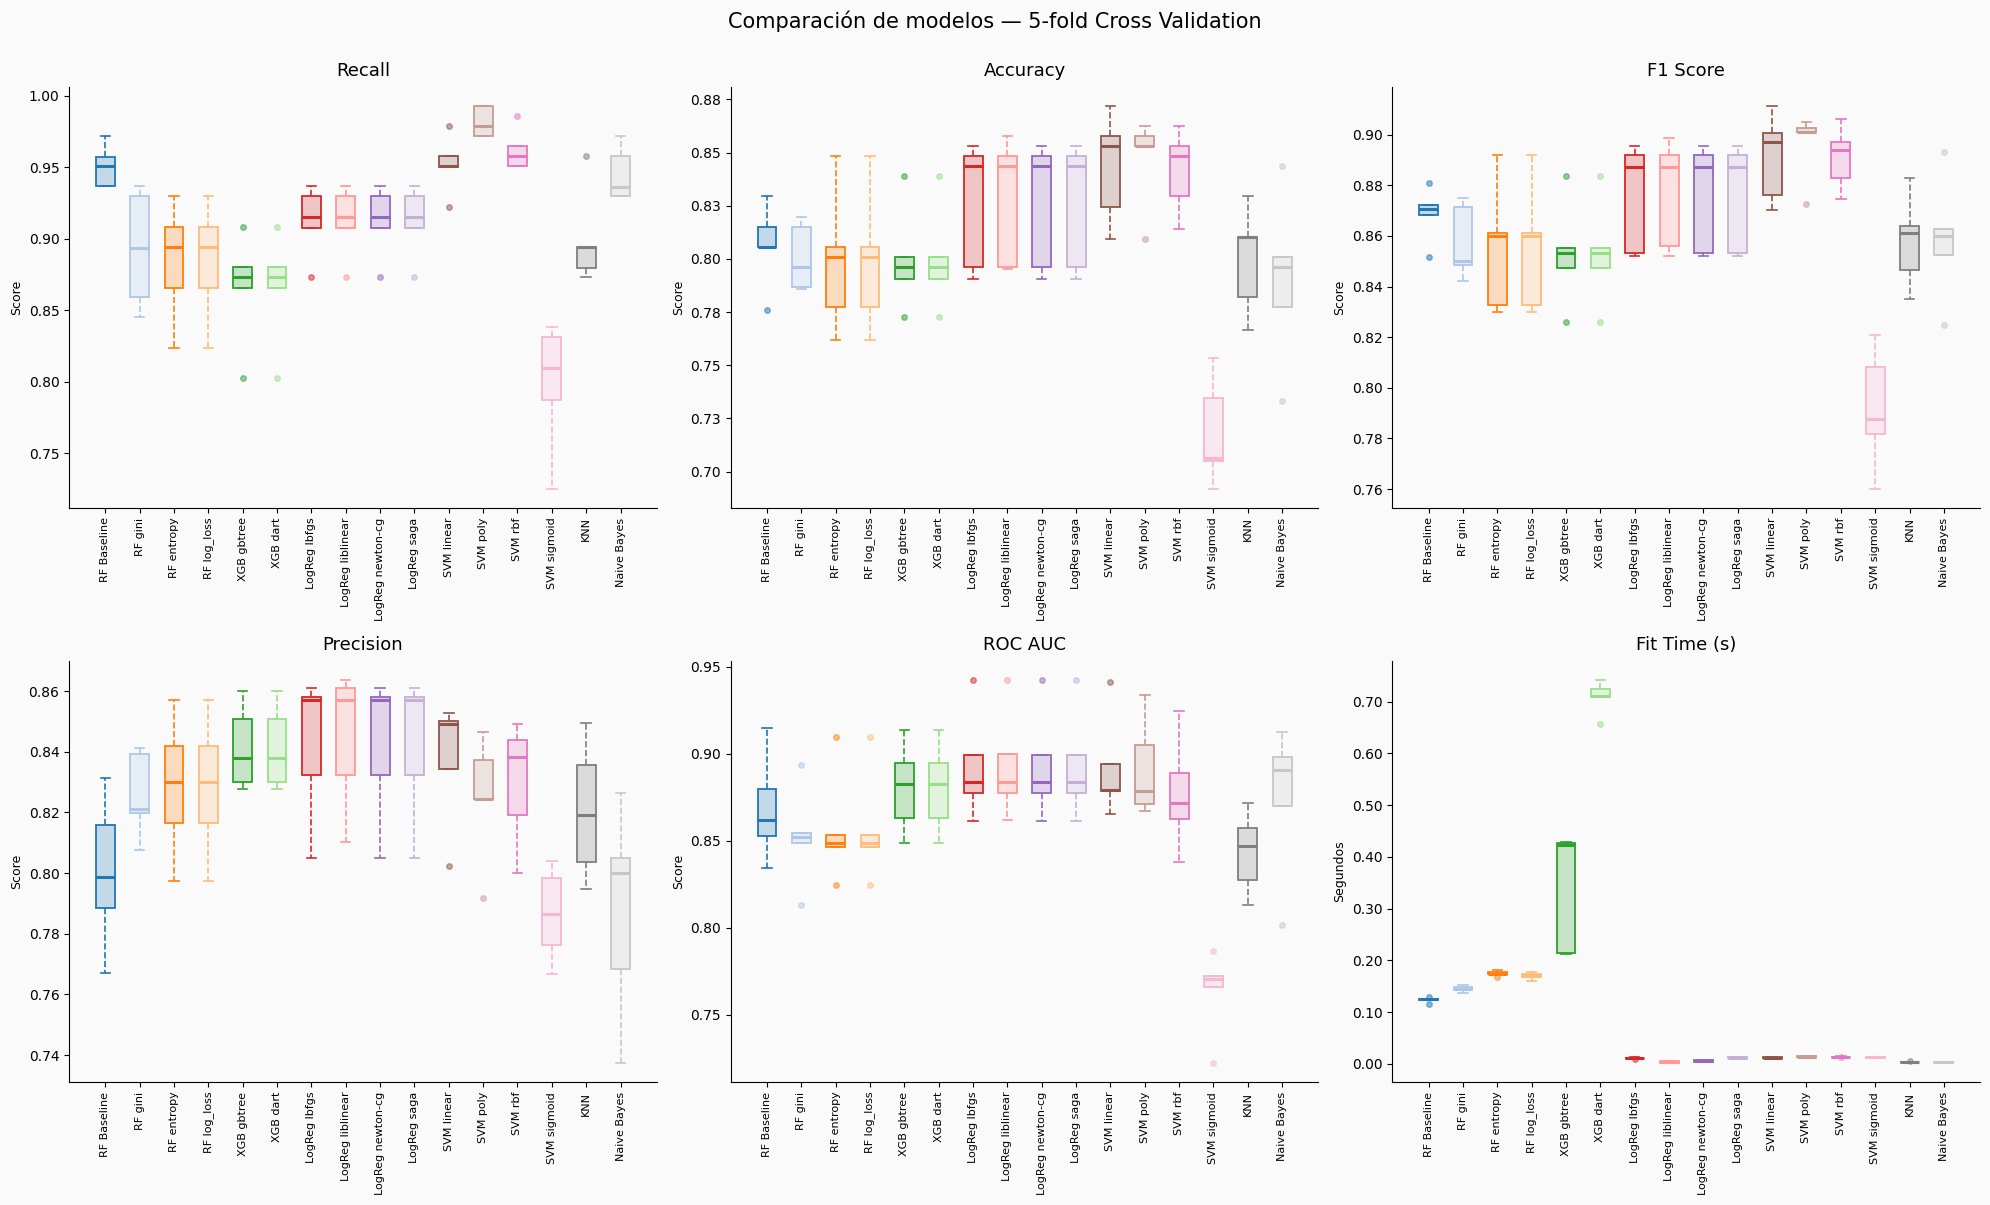

In [ ]:
# Paleta: un color por modelo
cmap = plt.get_cmap("tab20")
colors = {nombre: cmap(i % 20) for i, nombre in enumerate(rendimiento_clf)}

METRICAS = ['test_recall', 'test_accuracy', 'test_f1', 'test_precision', 'test_roc_auc', 'fit_time']
TITULOS  = ['Recall', 'Accuracy', 'F1 Score', 'Precision', 'ROC AUC', 'Fit Time (s)']

def compare_models_grid(rendimiento_clf):
    labels = list(rendimiento_clf.keys())
    fig, axs = plt.subplots(2, 3, figsize=(20, 12))
    fig.patch.set_facecolor("#FAFAFA")

    for idx, (metrica, titulo) in enumerate(zip(METRICAS, TITULOS)):
        ax = axs[idx // 3, idx % 3]
        ax.set_facecolor("#FAFAFA")

        for i, label in enumerate(labels):
            col = colors[label]
            ax.boxplot(
                rendimiento_clf[label][metrica],
                positions=[i], widths=0.55, patch_artist=True, manage_ticks=False,
                boxprops=dict(facecolor=(*col[:3], 0.25), color=col, linewidth=1.3),
                medianprops=dict(color=col, linewidth=2.2),
                whiskerprops=dict(color=col, linewidth=1.2, linestyle="--"),
                capprops=dict(color=col, linewidth=1.2),
                flierprops=dict(marker="o", markerfacecolor=col,
                                markeredgecolor=col, alpha=0.5, markersize=4),
            )

        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=90, fontsize=8)
        ax.set_title(titulo, fontsize=13, fontweight="medium", pad=8)
        ax.spines[["top", "right"]].set_visible(False)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))

        if metrica == 'fit_time':
            ax.set_ylabel("Segundos", fontsize=9)
        else:
            ax.set_ylabel("Score", fontsize=9)

    fig.suptitle("Comparación de modelos — 5-fold Cross Validation",
                 fontsize=15, fontweight="medium", y=1.0)
    plt.tight_layout()
    plt.savefig("model_comparison_grid.png", dpi=150, bbox_inches="tight")
    plt.show()

compare_models_grid(rendimiento_clf)

## Tabla resumen

Promedio de cada métrica a través de los *folds*, junto con su desviación estándar y el tiempo de entrenamiento.

In [ ]:
METRICAS_SCORE = ["recall", "accuracy", "f1", "precision", "roc_auc"]

def build_summary(rendimiento_clf):
    rows = []
    for nombre, cv in rendimiento_clf.items():
        row = {"modelo": nombre}
        for m in METRICAS_SCORE:
            vals = cv[f"test_{m}"]
            row[m] = vals.mean()
            row[f"{m}_std"] = vals.std()
        row["fit_time"] = cv["fit_time"].mean()
        rows.append(row)
    return pd.DataFrame(rows)

resumen = build_summary(rendimiento_clf)
cols_resumen = ["modelo"] + METRICAS_SCORE + ["fit_time"]
resumen[cols_resumen].sort_values("recall", ascending=False) \
       .style.format({m: "{:.4f}" for m in METRICAS_SCORE} | {"fit_time": "{:.3f}s"}) \
       .background_gradient(cmap="Greens", subset=METRICAS_SCORE)

,modelo,recall,accuracy,f1,precision,roc_auc,fit_time
11,SVM poly,0.9817,0.8472,0.8964,0.8250,0.8910,0.013s
12,SVM rbf,0.9619,0.8415,0.8910,0.8301,0.8770,0.014s
10,SVM linear,0.9520,0.8434,0.8911,0.8377,0.8917,0.012s
0,RF Baseline,0.9506,0.8064,0.8687,0.8003,0.8685,0.124s
15,Naive Bayes,0.9450,0.7903,0.8587,0.7874,0.8744,0.003s
7,LogReg liblinear,0.9125,0.8282,0.8773,0.8448,0.8929,0.004s
6,LogReg lbfgs,0.9125,0.8263,0.8761,0.8427,0.8927,0.012s
8,LogReg newton-cg,0.9125,0.8263,0.8761,0.8427,0.8927,0.005s
9,LogReg saga,0.9125,0.8263,0.8761,0.8427,0.8927,0.012s
14,KNN,0.8998,0.7998,0.8580,0.8206,0.8432,0.004s


## Selección del mejor modelo — *score* compuesto ponderado

Para elegir el mejor modelo de forma objetiva combinamos las métricas en un único score usando
los pesos definidos para este problema. Como el objetivo de negocio prioriza no dejar pasar
oportunidades de alto valor, el recall es la métrica con mayor peso:

| Métrica | Peso |
|---|---|
| Recall | 40 % |
| ROC AUC | 20 % |
| F1 Score | 20 % |
| Accuracy | 10 % |
| Precision | 10 % |

$$\text{score} = 0.40\cdot\text{recall} + 0.20\cdot\text{ROC AUC} + 0.20\cdot\text{F1} + 0.10\cdot\text{accuracy} + 0.10\cdot\text{precision}$$

El resultado es una lista ordenada de los 16 modelos de mayor a menor score.

In [ ]:
# Pesos del score compuesto (deben sumar 1)
PESOS = {"recall": 0.40, "accuracy": 0.10, "f1": 0.20, "precision": 0.10, "roc_auc": 0.20}
assert abs(sum(PESOS.values()) - 1.0) < 1e-9, "Los pesos deben sumar 1"

def rank_models(rendimiento_clf, pesos):
    df = build_summary(rendimiento_clf)
    df["score"] = sum(pesos[m] * df[m] for m in METRICAS_SCORE)
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    df.index += 1                       # ranking desde 1
    df.index.name = "ranking"
    return df

ranking = rank_models(rendimiento_clf, PESOS)

cols_show = ["modelo"] + METRICAS_SCORE + ["score", "fit_time"]
print("="*78)
print("  RANKING DE MODELOS — score ponderado (recall 40%, roc_auc 20%, f1 20%, acc 10%, prec 10%)")
print("="*78)
print(ranking[cols_show].to_string(float_format=lambda x: f"{x:.4f}"))

ganador = ranking.loc[1, "modelo"]
print(f"\n  >>> MEJOR MODELO: {ganador}  (score = {ranking.loc[1, 'score']:.4f})")

  RANKING DE MODELOS — score ponderado (recall 40%, roc_auc 20%, f1 20%, acc 10%, prec 10%)
                   modelo  recall  accuracy     f1  precision  roc_auc  score  fit_time
ranking                                                                                
1                SVM poly  0.9817    0.8472 0.8964     0.8250   0.8910 0.9174    0.0133
2                 SVM rbf  0.9619    0.8415 0.8910     0.8301   0.8770 0.9055    0.0138
3              SVM linear  0.9520    0.8434 0.8911     0.8377   0.8917 0.9055    0.0125
4             RF Baseline  0.9506    0.8064 0.8687     0.8003   0.8685 0.8884    0.1242
5        LogReg liblinear  0.9125    0.8282 0.8773     0.8448   0.8929 0.8864    0.0040
6        LogReg newton-cg  0.9125    0.8263 0.8761     0.8427   0.8927 0.8857    0.0053
7            LogReg lbfgs  0.9125    0.8263 0.8761     0.8427   0.8927 0.8857    0.0116
8             LogReg saga  0.9125    0.8263 0.8761     0.8427   0.8927 0.8857    0.0124
9             Naive Bayes  0

### Ranking visual
El gráfico de barras del score compuesto, permite comparar de manera integral el desempeño de los modelos. Se confirma que los modelos basados en SVM presentaron un mejor desempeño global.

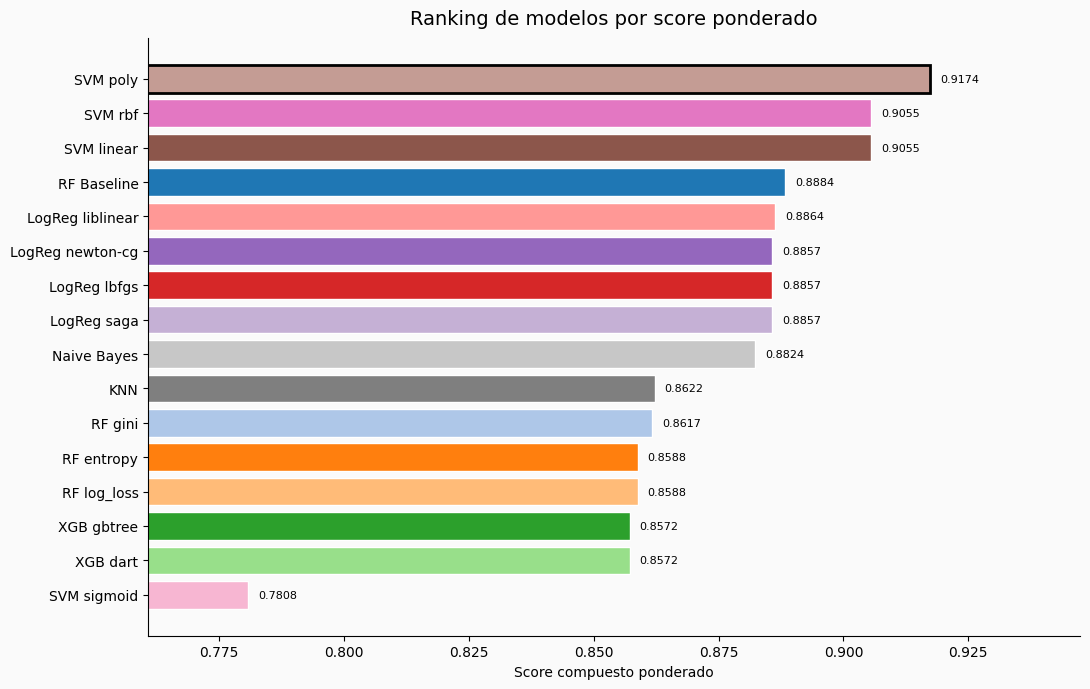

In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

orden = ranking.sort_values("score")
barras = ax.barh(orden["modelo"], orden["score"],
                 color=[colors[m] for m in orden["modelo"]], edgecolor="white")

# Resaltar al ganador
for barra, modelo in zip(barras, orden["modelo"]):
    if modelo == ganador:
        barra.set_edgecolor("black")
        barra.set_linewidth(2)

for barra, val in zip(barras, orden["score"]):
    ax.text(val + 0.002, barra.get_y() + barra.get_height()/2,
            f"{val:.4f}", va="center", fontsize=8)

ax.set_xlabel("Score compuesto ponderado", fontsize=10)
ax.set_title("Ranking de modelos por score ponderado", fontsize=14, fontweight="medium", pad=10)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(orden["score"].min() - 0.02, orden["score"].max() + 0.03)
plt.tight_layout()
plt.savefig("ranking_score_ponderado.png", dpi=150, bbox_inches="tight")
plt.show()

# Los modelos con los cuales se decide continuar para la optimización son: SVM poly, SVM rbf, SVM linear y RF Baseline

# Optimización de hiperparámetros con Grid Search — RF Baseline y SVM poly
En esta etapa buscamos optimizar los hiperparámetros sobre los modelos con mejor desempeño inicial de Random Forest y SVM poly, utilizando Recall como métrica principal.

In [ ]:
def rf_entry(criterion):
    return {"estimator": RandomForestClassifier(criterion=criterion, random_state=SEED, n_jobs=-1),
            "space": {"n_estimators":      [100, 300, 600],
                      "max_depth":         sorted(set([3, max(3, n_vars // 2), n_vars])),
                      "min_samples_split": [5, 10, 20],
                      "min_samples_leaf":  [5, 10],
                      "max_features":      ["sqrt", "log2"],
                      "class_weight": ["balanced", None]}}

def svm_entry(kernel):
    space = {"C": [0.1, 1, 10, 100], "class_weight": ["balanced", None]}
    if kernel in ("rbf", "poly"):
        space["gamma"] = [1e-3, 1e-2, 1e-1]
    if kernel == "poly":
        space["degree"] = [2, 3]
        space["coef0"]  = [0.0, 1.0]
    return {"estimator": SVC(kernel=kernel, random_state=SEED), "space": space}

In [ ]:
SEARCH_REGISTRY = {
    "RF Baseline": rf_entry("gini"),
    "SVM poly":    svm_entry("poly"),
}

## Ejecución de la búsqueda en malla (Grid Search)

In [ ]:
# Modelos a optimizar con Grid Search
modelos_opt = ["RF Baseline", "SVM poly"]
print("Modelos a optimizar:", modelos_opt)

resultados_grid = {}
for nombre in modelos_opt:
    entry = SEARCH_REGISTRY[nombre]
    opt = GridSearchCV(estimator=entry["estimator"],
                       param_grid=entry["space"],
                       scoring='recall',
                       cv=5, n_jobs=-1, refit=True)
    opt.fit(X_train_scaled, y_train)
    resultados_grid[nombre] = opt
    n_comb = len(opt.cv_results_["params"])
    print(f"{nombre:18s} | {n_comb:4d} combinaciones | score CV tuneado = {opt.best_score_:.4f}")

Modelos a optimizar: ['RF Baseline', 'SVM poly']
RF Baseline        |  216 combinaciones | score CV tuneado = 0.9831
SVM poly           |   96 combinaciones | score CV tuneado = 1.0000


Ambos modelos mostraron resultados altos en validación cruzada, aunque SVM poly obtuvo el score más alto, mientras que Random Forest mantuvo un desempeño competitivo y más fácil de interpretar.

### Mejores hiperparámetros encontrados
Se buscan hiperparámetros que permitan ajustar ambos modelos para mejorar desempeño y reducir riesgo de sobreajuste.

In [ ]:
for nombre in modelos_opt:
    print("=" * 60)
    print(f"{nombre}  |  score CV = {resultados_grid[nombre].best_score_:.4f}")
    for k, v in resultados_grid[nombre].best_params_.items():
        print(f"  {k:18s}: {v}")

RF Baseline  |  score CV = 0.9831
  class_weight      : None
  max_depth         : 3
  max_features      : sqrt
  min_samples_leaf  : 5
  min_samples_split : 5
  n_estimators      : 600
SVM poly  |  score CV = 1.0000
  C                 : 0.1
  class_weight      : balanced
  coef0             : 0.0
  degree            : 3
  gamma             : 0.001


En Random Forest, se limitaron ciertas complejidades del árbol para favorecer generalización, mientras que SVM poly encontró una configuración orientada a maximizar el desempeño manteniendo balance entre clases. En general, los parámetros obtenidos muestran modelos mejor adaptados a los datos del problema.

## Evaluación final en el conjunto de *test*

Evaluamos los dos modelos ganadores ya optimizados (`RF Baseline` y `SVM poly`)
sobre el conjunto de *test*, que el modelo nunca vio durante el ajuste de hiperparámetros.

Reportamos dos cosas:

1. **Scores en test** — recall, accuracy, F1, precision y ROC AUC para cada modelo.
2. **Distribución de probabilidad por clase** — cómo separa cada modelo las dos clases. Para cada
   observación de *test* tomamos la probabilidad estimada de pertenecer a la clase positiva,
   `P(clase = 1)`, y comparamos su distribución según la **clase real**.


In [ ]:
# === Modelos finales (mejores hiperparámetros) y scores en TEST ===
from sklearn.metrics import (recall_score, accuracy_score, f1_score,
                             precision_score, roc_auc_score)

# Reconstruimos cada modelo ganador ya optimizado.
# RF: usamos directamente el best_estimator_ del Grid Search.
# SVM: reajustamos con probability=True para poder obtener predict_proba.
modelos_finales = {}
for nombre in modelos_opt:
    if nombre == "SVM poly":
        est = SVC(kernel="poly", probability=True, random_state=SEED,
                  **resultados_grid[nombre].best_params_)
        est.fit(X_train_scaled, y_train)
    else:
        est = resultados_grid[nombre].best_estimator_
    modelos_finales[nombre] = est

# Probabilidad de la clase positiva y scores sobre el conjunto de test
probas_test, filas_score = {}, []
for nombre, est in modelos_finales.items():
    clases  = list(est.classes_)
    p_pos   = est.predict_proba(X_test_scaled)[:, clases.index(1)]   # P(clase = 1)
    y_pred  = (p_pos >= 0.5).astype(int)
    probas_test[nombre] = p_pos
    filas_score.append({
        "modelo":    nombre,
        "recall":    recall_score(y_test, y_pred),
        "accuracy":  accuracy_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "roc_auc":   roc_auc_score(y_test, p_pos),
    })

scores_test = pd.DataFrame(filas_score).set_index("modelo")

print("=" * 60)
print("  SCORES EN EL CONJUNTO DE TEST")
print("=" * 60)
print(scores_test.to_string(float_format=lambda x: f"{x:.4f}"))

# Tabla con formato (resaltado por columna)
scores_test.style.format("{:.4f}").background_gradient(cmap="Greens")

  SCORES EN EL CONJUNTO DE TEST (umbral = 0.5)
             recall  accuracy     f1  precision  roc_auc
modelo                                                  
RF Baseline  0.9966    0.7810 0.8542     0.7474   0.8774
SVM poly     1.0000    0.6438 0.7833     0.6438   0.1238


,recall,accuracy,f1,precision,roc_auc
modelo,,,,,
RF Baseline,0.9966,0.7810,0.8542,0.7474,0.8774
SVM poly,1.0000,0.6438,0.7833,0.6438,0.1238


### Comparación de las distribuciones de probabilidad por clase

Cada panel corresponde a uno de los modelos ganadores. Se grafican, superpuestas, las distribuciones
de `P(clase = 1)` separadas por la **clase real** (0 y 1). La línea punteada marca el umbral de
decisión 0.5: cuanto menor sea el solapamiento de ambas curvas alrededor de esa línea, mejor
discrimina el modelo.

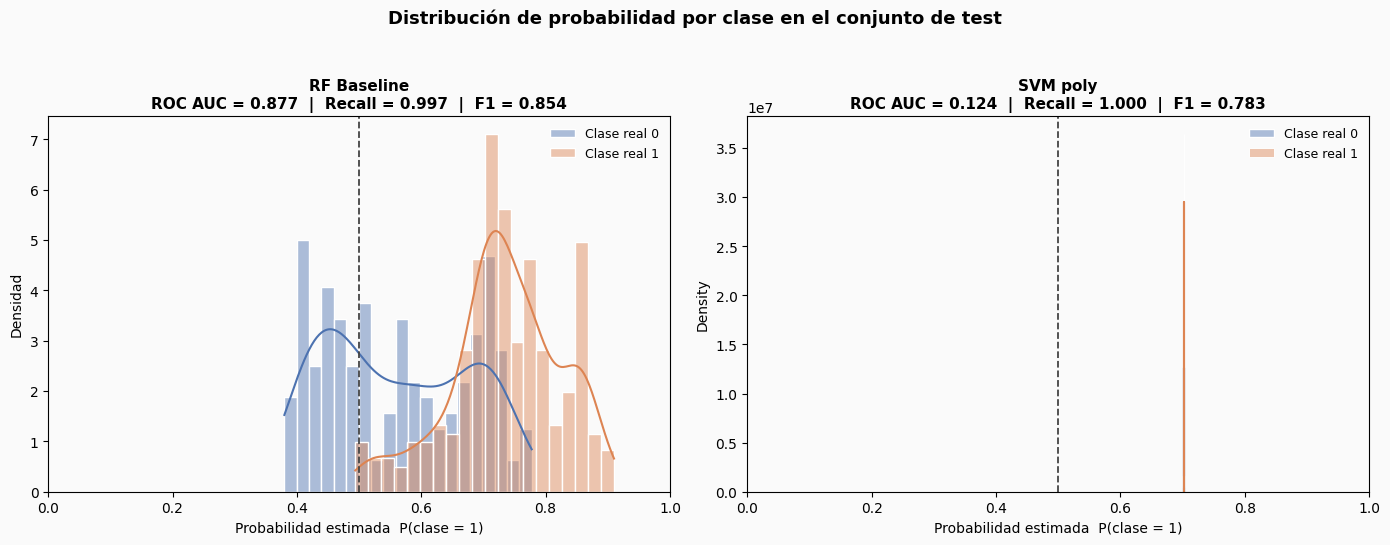

In [ ]:
# === Distribución de P(clase=1) por clase real, para cada modelo ganador ===
COL_CLASE = {0: "#4C72B0", 1: "#DD8452"}   # azul = clase 0, naranja = clase 1

fig, axes = plt.subplots(1, len(modelos_opt), figsize=(14, 5.2), sharey=False)
fig.patch.set_facecolor("#FAFAFA")
axes = np.atleast_1d(axes)

for ax, nombre in zip(axes, modelos_opt):
    ax.set_facecolor("#FAFAFA")
    p_pos = probas_test[nombre]
    for c in (0, 1):
        sns.histplot(p_pos[y_test == c], bins=20, stat="density", kde=True,
                     ax=ax, color=COL_CLASE[c], alpha=0.45,
                     edgecolor="white", label=f"Clase real {c}")
    ax.axvline(0.5, ls="--", lw=1.3, color="#444444")
    auc = scores_test.loc[nombre, "roc_auc"]
    rec = scores_test.loc[nombre, "recall"]
    f1v = scores_test.loc[nombre, "f1"]
    ax.set_title(f"{nombre}\nROC AUC = {auc:.3f}  |  Recall = {rec:.3f}  |  F1 = {f1v:.3f}",
                 fontsize=11, weight="bold")
    ax.set_xlabel("Probabilidad estimada  P(clase = 1)")
    ax.set_xlim(0, 1)
    ax.legend(frameon=False, fontsize=9)

axes[0].set_ylabel("Densidad")
fig.suptitle("Distribución de probabilidad por clase en el conjunto de test",
             fontsize=13, weight="bold", y=1.04)
plt.tight_layout()
plt.show()

## Conclusión

El **score compuesto ponderado** permitió integrar distintas métricas en un solo criterio de evaluación, priorizando el Recall (40%) debido a la importancia de identificar la mayor cantidad posible de proyectos positivos sin descuidar el desempeño general del modelo.

A partir del ranking inicial, se seleccionaron dos de los modelos con mejor rendimiento para optimizar hiperparámetros y validar si podían mejorar su capacidad predictiva:
*   SVM poly
*   Random Forest (baseline)

 Aunque SVM poly obtuvo el score más alto tras la optimización, Random Forest mantuvo un desempeño competitivo.

> **Nota:** si dos modelos quedan muy cerca en el *score*, conviene revisar también la columna
> `fit_time` (costo de entrenamiento) y la dispersión entre *folds* (desviación estándar) antes de
> tomar la decisión final.


### Referencias
*   Géron, A. (2022). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (3rd ed.). O´Reilly Media.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import subprocess

activity_folder = '/content/drive/MyDrive/2026 T2 Proyecto Integrador/Proyecto_Integrador_Eq9/'
cmd = [
    "jupyter", "nbconvert",
    f"{activity_folder}Avance4.09_V2.jason",
    "--to", "html",
    "--template", "classic",
    "--output", "Avance4.09_V2.html"
]

subprocess.run(cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

CompletedProcess(args=['jupyter', 'nbconvert', '/content/drive/MyDrive/2026 T2 Proyecto Integrador/Proyecto_Integrador_Eq9/Avance4.09_V2.jason', '--to', 'html', '--template', 'classic', '--output', 'Avance4.09_V2.html'], returncode=255)